# Exercise 1


## Supervised Learning- Classification Models

---

## Overview

Welcome to this excercise. We are now going to use our new skills to build our supervised learning models that use classification approach.

---


In [1]:
!pip install statsmodels

In [2]:
import sys
import os

# Manually set the path relative to the py file's location that you want to import
func_lib_path = os.path.abspath(os.path.join(os.getcwd(), '../../'))# Add the path to sys.path
sys.path.append(func_lib_path)

# Now you can import func_lib
import func_lib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [3]:
# Retrieve historical price data.
# - Use the 'createHistPrices()' function from 'func_lib' to get historical price data.
# - Assign the result to the variable 'historical_prices'.

historical_prices = func_lib.create_hist_prices()

# Define the list of momentum periods.
# - Create a list containing different time periods for calculating momentum indicators.
# - Assign this list to the variable 'list_of_momentums'.

list_of_momentums = [1, 5, 15, 20]

# Compute returns based on historical prices and momentum periods.
# - Use the 'computingReturns()' function from 'func_lib' with 'historical_prices' and 'list_of_momentums' as inputs.
# - Assign the result to the variable 'total_returns'.

total_returns = func_lib.compute_returns(historical_prices, list_of_momentums)

# Remove any rows with missing values from the returns data.
# - Use the 'dropna()' method to remove rows with NaN values from 'total_returns'.
# - Apply the change in place to modify the DataFrame directly.

total_returns.dropna(inplace=True)

[*********************100%%**********************]  501 of 501 completed

1 Failed download:
['SW']: YFChartError("%ticker%: Data doesn't exist for startDate = 946702800, endDate = 1714536000")


In [4]:
# Convert 'F_1_d_returns' to binary values based on whether they are positive or not.
# - Use the 'apply()' function with a lambda expression to create a new column 'F_1_d_returns_Ind'.
# - The lambda expression assigns 1 if the value is greater than 0, otherwise assigns 0.

total_returns['F_1_d_returns_Ind'] = total_returns['F_1_d_returns'].apply(lambda x: 1 if x > 0 else 0)
# Display the updated DataFrame.
total_returns.head()

F_1_d_returns  1_d_returns ...

In [5]:
# Determine the split index for 70% of the dates.
# - Extract the unique dates from the index of 'total_returns'.
# - Calculate the split date by indexing into the unique dates to get the date corresponding to 70% of the total length of unique dates.
# - Assign this date to the variable 'split_date' and display it.

unique_dates = total_returns.index.get_level_values('Date').unique()
split_date = unique_dates[int(0.7 * len(unique_dates))]
print(split_date)

2017-01-20 00:00:00


In [6]:
# Create the training set: all data before the split date.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is earlier than 'split_date'.
# - Assign this subset of data to the variable 'train_data'.

train_data = total_returns.loc[total_returns.index.get_level_values('Date') < split_date]

# Create the testing set: all data from the split date onwards.
# - Use the 'loc[]' indexer to select rows from 'total_returns' where the date in the index is equal to or later than 'split_date'.
# - Assign this subset of data to the variable 'test_data'.

test_data = total_returns.loc[total_returns.index.get_level_values('Date') >= split_date]

In [7]:
# Extract the target variable for testing.
# - Select the 'F_1_d_returns' column from the 'test_data' DataFrame.
# - Assign this column to the variable 'total_returns'.

total_returns = test_data['F_1_d_returns']

In [8]:
# Define the features and target variables.
# - Specify the columns to be used as features ('1_d_returns', '5_d_returns', '15_d_returns', '20_d_returns').
# - Specify the column to be used as the target variable ('F_1_d_returns_Ind').

features = ['1_d_returns', '5_d_returns', '15_d_returns', '20_d_returns']
target   = ['F_1_d_returns_Ind']

# Split the data into training and testing sets.
# - Extract the feature columns from the training data and testing data.
# - Extract the target column from the training data and testing data.

X_train = train_data[features]
X_test  = test_data[features]
y_train = train_data[target]
y_test  = test_data[target]

In [9]:
# Standardize the features.
# - Create an instance of 'StandardScaler' for scaling the features.
# - Fit the scaler to the training data and transform both the training and testing feature sets.
# - Convert the scaled arrays back to DataFrames with the same index and column names as the original feature sets.

scaler = StandardScaler()

# Scale the training features
X_train_scaled = scaler.fit_transform(X_train)
# Scale the testing features
X_test_scaled  = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  index=X_test.index,  columns=features)

In [10]:
# Add a constant to the model (intercept).
# - Use the 'add_constant()' function from the statsmodels library to add an intercept term to the feature sets.
# - Apply this to both the training and testing feature sets.

X_train_scaled_const_add = sm.add_constant(X_train_scaled)
X_test_scaled_const_add  = sm.add_constant(X_test_scaled)

# Create and fit a logistic regression model.
# - Initialize a logistic regression model using 'sm.Logit()' with the target and feature sets including the intercept.
# - Fit the model to the training data.
# - Display a summary of the fitted model.

model = sm.Logit(y_train, X_train_scaled_const_add)
model = model.fit()
print(model.summary2())

Optimization terminated successfully.
         Current function value: 0.692888
         Iterations 3
                          Results: Logit
Model:              Logit            Method:           MLE
Dependent Variable: y                Pseudo R-squ.:  0.0000
Date:               2024-05-01       AIC:          292532.6132
No. Observations:   211050           BIC:          292583.9124
Df Model:           4                Log-Likelihood: -1.4626e+05
Df Residuals:       211045           LL-Null:        -1.4626e+05
Converged:          True             LLR p-value:      0.83647
No. Iterations:     3
Scale:              1.0000
-------------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z|   [0.025   0.975]
-------------------------------------------------------------------
const            0.0318   0.0044  7.3049  0.0000   0.0233   0.0403
1_d_returns      0.0034   0.0049  0.6919  0.4890  -0.0062   0.0129
5_d_returns      0.0034   0.0058  

In [11]:
# Set the model name.
# - Assign the name 'Log' to the variable 'model_name' to label the regression model.

model_name = 'Log'

# Make predictions using the fitted model.
# - Use 'model.predict()' to generate predictions based on the scaled testing features with the added constant.

y_pred = model.predict(X_test_scaled_const_add)

# Create DataFrames for the actual and predicted values.
# - Convert the true target values 'y_test' and predicted values 'y_pred' to DataFrames.
# - Rename the columns to 'F_1_d_returns' and 'model_name' respectively.

y_test_df  = pd.DataFrame(total_returns)
y_pred_df  = pd.DataFrame(y_pred, index=X_test_scaled.index)
y_pred_df.rename(columns={0: model_name}, inplace=True)

y_test_and_pred = y_test_df.join(y_pred_df)

In [12]:
# Define a trading strategy based on logistic regression predictions.
# - Create a function 'trading_strategy' that takes the predicted value 'y_pred' as input.
# - If the predicted value is greater than 0.5, return 1 (indicating a "Go long" signal).
# - Otherwise, return 0 (indicating no action or "Do nothing").

def trading_strategy(y_pred):
    if y_pred > 0.5:
        return 1  # Go long
    else:
        return 0  # Do nothing

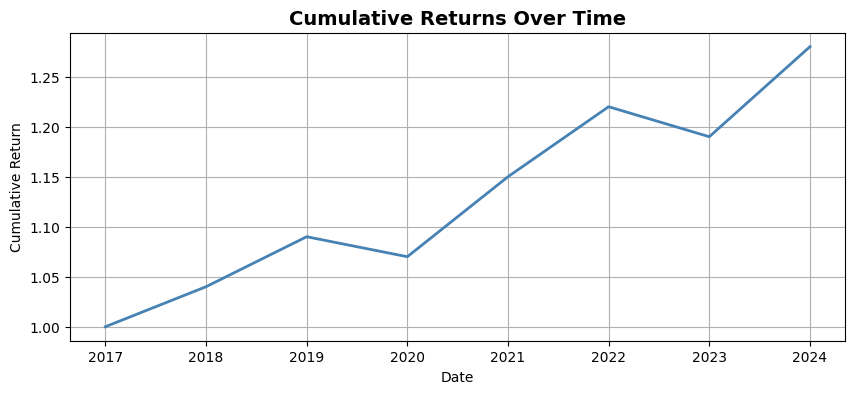

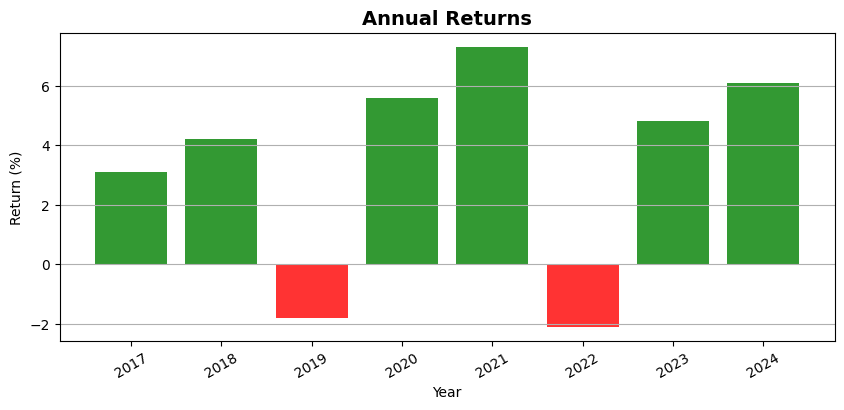

The CAGR is: 5.82%
Sharpe Ratio of Strategy: 0.47


In [13]:
# Compute performance metrics based on the predictions and actual returns.
# - Use the 'func_lib.compute_BM_Perf()' function to calculate cumulative and calendar returns.
# - Pass the DataFrame 'y_test_and_pred' containing the actual and predicted values as an argument.

cum_returns, calendar_returns = func_lib.compute_BM_Perf(y_test_and_pred)

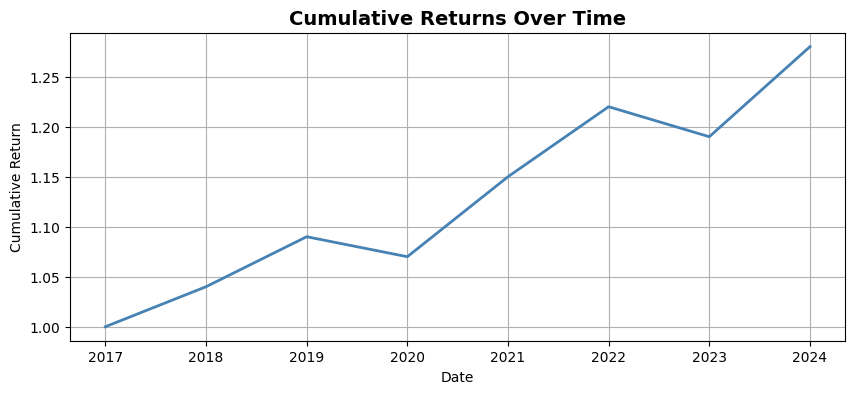

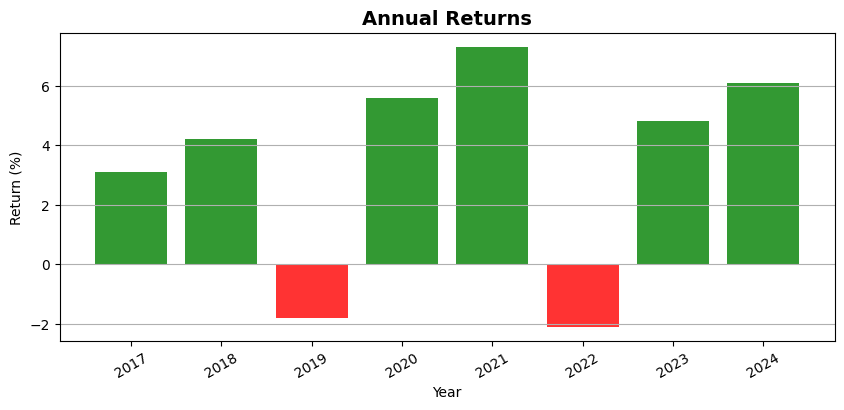

The CAGR is: 3.14%
Sharpe Ratio of Strategy: 0.29


In [14]:
# Compute strategy performance metrics.
# - Use the 'func_lib.compute_strat_perf()' function to calculate the performance of the trading strategy.
# - Pass the following arguments:
#   - 'y_test_and_pred': The DataFrame containing actual and predicted values.
#   - 'cum_returns': Cumulative returns calculated previously.
#   - 'calendar_returns': Calendar returns calculated previously.
#   - 'trading_strategy': The function defining the trading strategy based on predictions.
#   - 'model_name': The name of the model to include in the performance evaluation.

cum_returns, calendar_returns = func_lib.compute_strat_perf(y_test_and_pred, cum_returns, calendar_returns, trading_strategy, model_name)